# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data file comprising model parameters and simulation profile
load readonly/sysData.mat u x z SigmaW SigmaV

% Reserve storage for computed results, for plotting
nt             = length(x); 
xhatEKFstore   = zeros(1,nt);
boundEKFstore  = zeros(1,nt);
xhatIEKFstore  = zeros(1,nt);
boundIEKFstore = zeros(1,nt);
t = 0:nt-1;

% Covariance values
SigmaX0 = 1;   % uncertainty of initial state
xhat0   = 0.1;
 
rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the extended Kalman filter
The next notebook cells implement the initialization and iteration functions for the EKF.

In [3]:
% EKF initialization function, called once at the beginning of the simulation
function ekfData = initEKF(xhat0,SigmaX0,priorU,SigmaW,SigmaV)
  ekfData.xhat   = xhat0;    % Initial state description  
  ekfData.SigmaX = SigmaX0;  % Initial estimation-error covariance 
  ekfData.SigmaV = SigmaV;   % Sensor-noise covariance 
  ekfData.SigmaW = SigmaW;   % Process-noise covariance
  ekfData.priorU = priorU;   % Previous value of input force
  ekfData.Qbump  = 5;        % In case SigmaX collapses
end

In [4]:
% EKF iteration function, called once every measurement interval
function [xhat,bounds,ekfData] = iterEKF(uk,zk,ekfData)
  % Get data stored in ekfData structure
  priorU = ekfData.priorU;
  SigmaX = ekfData.SigmaX;
  SigmaV = ekfData.SigmaV;
  SigmaW = ekfData.SigmaW;
  xhat   = ekfData.xhat;
  
  % EKF Step 0: Compute Ahat[k-1], Bhat[k-1]
  Ahat = (25.5 - 24*xhat^2+0.5*xhat^4)/(1+xhat^2)^2;
  Bhat = 1;
  
  % Step 1a: State estimate time update
  xhat = 0.5*xhat+25*xhat/(1+xhat^2)+priorU;
  
  % Step 1b: Error covariance time update
  %          sigmaminus(k) = Ahat(k-1)*sigmaplus(k-1)*Ahat(k-1)' + ...
  %                          Bhat(k-1)*sigmawtilde*Bhat(k-1)'
  SigmaX = Ahat*SigmaX*Ahat' + SigmaW';
  
  % Step 1c: Output estimate
  zhat = xhat^2/20;
  
  % Step 2a: Estimator gain matrix
  Chat = xhat/10; Dhat = 1;
  SigmaZ = Chat*SigmaX*Chat' + Dhat*SigmaV*Dhat';
  L = SigmaX*Chat'/SigmaZ;
  
  % Step 2b: State estimate measurement update
  r = zk - zhat; % residual.  Use to check for sensor errors...
  % if r^2 > 100*SigmaZ, L(:)=0.0; end 
  xhat = xhat + L*r;
  
  % Step 2c: Error covariance measurement update
  % SigmaX = SigmaX - L*SigmaZ*L';
  SigmaX = (1-L*Chat)*SigmaX;
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  ekfData.priorU = uk;
  ekfData.SigmaX = SigmaX;
  ekfData.xhat = xhat;
  bounds = 3*sqrt(diag(SigmaX));
end

### Implementing the extended Kalman filter
The next notebook cell implements the main code of the extended Kalman filter.

In [5]:
% Create ekfData structure and initialize variables 
ekfData = initEKF(xhat0,SigmaX0,u(1),SigmaW,SigmaV);
  
% Now, enter loop for remainder of time, where we update the EKF
% once per sample interval
for k = 2:nt
  uk = u(k); % "measure" input 
  zk = z(k); % "measure" nonlinear output
    
  % Update model states
  [xhatEKFstore(k),boundEKFstore(k),ekfData] = iterEKF(uk,zk,ekfData);
end
ekfErr = x - xhatEKFstore;
ekfBnd = boundEKFstore;

### Plot simulation outputs from the extended Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

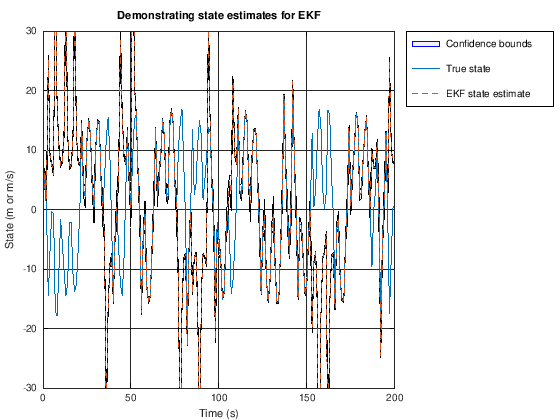

In [6]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatEKFstore-boundEKFstore fliplr(xhatEKFstore+boundEKFstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on

h2 = plot(t,x,t,xhatEKFstore,'--'); ylim([-30 30]);
legend([h2;h1a],{'True state','EKF state estimate',...
  'Confidence bounds'},'Location','BestOutside'); 
title('Demonstrating state estimates for EKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

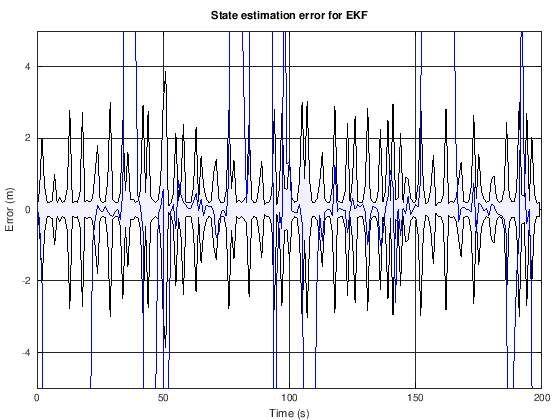

In [7]:
fill([t fliplr(t)],[-boundEKFstore fliplr(boundEKFstore)],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr,'b'); ylim([-5 5])
title('State estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

In [8]:
% Compute and output some statistics
fprintf('RMS state estimation error = %g\n',rms(ekfErr(:)));
ind = find(abs(ekfErr(:))>ekfBnd(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(ekfErr(:))*100);

RMS state estimation error = 16.9625
Time error outside bounds = 45%


### Helper functions for the iterated extended Kalman filter
The next notebook cells implement the initialization and iteration functions for the IEKF.

In [9]:
% IEKF initialization function, called once at the beginning of the simulation
function iekfData = initIEKF(xhat0,SigmaX0,priorU,SigmaW,SigmaV,NI)
  iekfData.xhat   = xhat0;    % Initial state description  
  iekfData.SigmaX = SigmaX0;  % Initial estimation-error covariance 
  iekfData.SigmaV = SigmaV;   % Sensor-noise covariance 
  iekfData.SigmaW = SigmaW;   % Process-noise covariance
  iekfData.priorU = priorU;   % Previous value of input force
  iekfData.Qbump  = 5;        % In case SigmaX collapses
  iekfData.NI     = NI;       % Number of iterations of IEKF meas update
end

In [10]:
% IEKF iteration function, called once every measurement interval
function [xhat,bounds,iekfData] = iterIEKF(uk,zk,iekfData)
  % Get data stored in ekfData structure
  priorU = iekfData.priorU;
  SigmaX = iekfData.SigmaX;
  SigmaV = iekfData.SigmaV;
  SigmaW = iekfData.SigmaW;
  xhat   = iekfData.xhat;
  NI     = iekfData.NI;
  
  % EKF Step 0: Compute Ahat[k-1], Bhat[k-1]
  Ahat = (25.5 - 24*xhat^2+0.5*xhat^4)/(1+xhat^2)^2;
  Bhat = 1;
  
  % Step 1a: State estimate time update
  xhat = 0.5*xhat+25*xhat/(1+xhat^2)+priorU;
  
  % Step 1b: Error covariance time update
  %          sigmaminus(k) = Ahat(k-1)*sigmaplus(k-1)*Ahat(k-1)' + ...
  %                          Bhat(k-1)*sigmawtilde*Bhat(k-1)'
  SigmaX = Ahat*SigmaX*Ahat' + SigmaW';

  xhatI = xhat;     
  SigmaXI = SigmaX;

  for j = 0:NI 
    Chat = xhatI/10; Dhat = 1;
    SigmaZ = Chat*SigmaX*Chat' + Dhat*SigmaV*Dhat';
    L = SigmaX*Chat'/SigmaZ;
    xhatI = xhat + L*(zk - xhatI^2/20 - Chat*(xhat-xhatI));
    SigmaXI = (1-L*Chat)*SigmaX;
  end

  xhat = xhatI;
  SigmaX = SigmaXI;
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  iekfData.priorU = uk;
  iekfData.SigmaX = SigmaX;
  iekfData.xhat = xhat;
  bounds = 3*sqrt(diag(SigmaX));
end

### Implementing the iterated extended Kalman filter
The next notebook cells implement the main code of the iterated extended Kalman filter.

In [11]:
NI = 5; % Iteration count for IEKF

% Create ekfData structure and initialize variables 
iekfData = initIEKF(xhat0,SigmaX0,u(1),SigmaW,SigmaV,NI);
    
% Now, enter loop for remainder of time, where we update the EKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input 
  zk = z(k); % "measure" nonlinear output
      
  % Update SOC (and other model states)
  [xhatIEKFstore(k),boundIEKFstore(k),iekfData] = iterIEKF(uk,zk,iekfData);
end
iekfErr = x - xhatIEKFstore;
iekfBnd = boundIEKFstore;

### Plot simulation outputs from the iterated extended Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

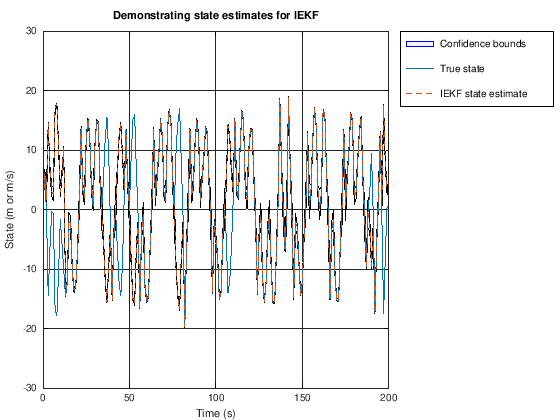

In [12]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatIEKFstore-boundIEKFstore fliplr(xhatIEKFstore+boundIEKFstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on

h2 = plot(t,x,t,xhatIEKFstore,'--'); ylim([-30 30]);
legend([h2;h1a],{'True state','IEKF state estimate',...
  'Confidence bounds'},'Location','BestOutside'); 
title('Demonstrating state estimates for IEKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

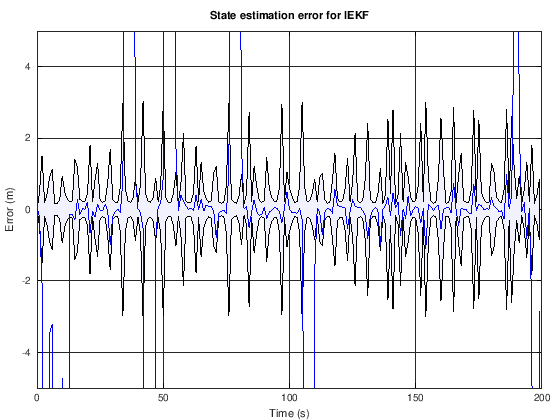

In [13]:
fill([t fliplr(t)],[-boundIEKFstore fliplr(boundIEKFstore)],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,iekfErr,'b'); ylim([-5 5])
title('State estimation error for IEKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

In [14]:
% Compute and output some statistics
fprintf('RMS state estimation error = %g\n',rms(iekfErr(:)));
ind = find(abs(iekfErr(:))>iekfBnd(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(iekfBnd(:))*100);

RMS state estimation error = 9.24123
Time error outside bounds = 21%
